the public SAEs are trained on GPT-2 Small and not on the custom 1-layer grokking model. So the first thing this notebook does is train a small SAE directly on the model's MLP activations.

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from tqdm.notebook import tqdm
from transformer_lens import HookedTransformer, HookedTransformerConfig

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

RESULTS_DIR = Path("../results/level3")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SAE_PATH = Path("../data/grokking_sae.pt")
MODEL_PATH = Path("../data/grokking_model.pt")
L1_RESULTS = Path("../results/level1/level1_results.json")
L2_RESULTS = Path("../results/level2/level2_results.json")

Using device: cpu


In [4]:
P = 113
EQ_TOKEN = P

all_a = torch.arange(P)
all_b = torch.arange(P)
aa, bb = torch.meshgrid(all_a, all_b, indexing='ij')
aa, bb = aa.flatten(), bb.flatten()
labels = (aa + bb) % P
inputs = torch.stack([aa, bb, torch.full_like(aa, EQ_TOKEN)], dim=1)

N = len(inputs)
idx = torch.randperm(N, generator=torch.Generator().manual_seed(42))
n_test = int(0.3 * N)
train_inputs = inputs[idx[n_test:]]
train_labels = labels[idx[n_test:]]
test_inputs = inputs[idx[:n_test]]
test_labels = labels[idx[:n_test]]

cfg = HookedTransformerConfig(
    n_layers=1, n_heads=4, d_model=128, d_head=32,
    d_mlp=512, act_fn="relu", normalization_type=None,
    d_vocab=P + 1, d_vocab_out=P, n_ctx=3,
    use_attn_result=True,
)
model = HookedTransformer(cfg)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device).eval()

with torch.no_grad():
    te_acc = (model(test_inputs.to(device))[:,-1,:].argmax(-1) == test_labels.to(device)).float().mean()
print(f"Test accuracy: {te_acc:.4f}")

Moving model to device:  cpu
Test accuracy: 1.0000


Define the SAE architecture

A sparse autoencoder is an encoder that projects up to a larger dictionary, applies ReLU to enforce non-negativity and sparsity, then decodes back. The L1 penalty on feature activations is what drives sparsity. Most features will be zero for any given input.

In [5]:
class SparseAutoencoder(nn.Module):
    def __init__(self, d_in, d_sae, l1_coeff=2e-4):
        super().__init__()
        self.d_in = d_in
        self.d_sae = d_sae
        self.l1_coeff = l1_coeff

        self.W_enc = nn.Parameter(torch.empty(d_in, d_sae))
        self.b_enc = nn.Parameter(torch.zeros(d_sae))
        self.W_dec = nn.Parameter(torch.empty(d_sae, d_in))
        self.b_dec = nn.Parameter(torch.zeros(d_in))

        nn.init.kaiming_uniform_(self.W_enc)
        nn.init.kaiming_uniform_(self.W_dec)
        self._normalise_decoder()

    def _normalise_decoder(self):
        """Keep decoder columns unit-norm (standard SAE training practice)."""
        with torch.no_grad():
            self.W_dec.data = nn.functional.normalize(self.W_dec.data, dim=1)

    def encode(self, x):
        """Returns feature activations: [batch, d_sae], non-negative."""
        return torch.relu((x - self.b_dec) @ self.W_enc + self.b_enc)

    def decode(self, f):
        """Reconstructs input from feature activations."""
        return f @ self.W_dec + self.b_dec

    def forward(self, x):
        f = self.encode(x)
        x_hat = self.decode(f)
        l2_loss = (x - x_hat).pow(2).sum(dim=-1).mean()
        l1_loss = f.abs().sum(dim=-1).mean()
        loss = l2_loss + self.l1_coeff * l1_loss
        return loss, x_hat, f, l2_loss, l1_loss


D_IN = model.cfg.d_mlp # 512
D_SAE = D_IN * 4 # 2048 features (standard 4x expansion ratio)


sae = SparseAutoencoder(d_in=D_IN, d_sae=D_SAE, l1_coeff=2e-2).to(device)
print(f"SAE: {D_IN} to {D_SAE} to {D_IN}")
print(f"Parameters: {sum(p.numel() for p in sae.parameters()):,}")

SAE: 512 to 2048 to 512
Parameters: 2,099,712


Collect MLP activations for SAE training

The SAE trains on the actual post-ReLU MLP activations from your grokking model. We collect all of them across the training set.

In [6]:
HOOK = "blocks.0.mlp.hook_post"

all_mlp_acts = []
with torch.no_grad():
    for i in range(0, len(train_inputs), 256):
        batch = train_inputs[i:i+256].to(device)
        _, cache = model.run_with_cache(batch, names_filter=HOOK)
        # Take activation at the "=" position only — that's where prediction happens
        all_mlp_acts.append(cache[HOOK][:, -1, :].cpu())

mlp_acts_train = torch.cat(all_mlp_acts, dim=0)  # [N_train, 512]
print(f"Training activations shape: {mlp_acts_train.shape}")
print(f"Mean activation: {mlp_acts_train.mean():.4f}")
print(f"Fraction zero (sparsity): {(mlp_acts_train == 0).float().mean():.4f}")

Training activations shape: torch.Size([8939, 512])
Mean activation: 3.9969
Fraction zero (sparsity): 0.4449


Train the SAE

First run trains and saves 

In [7]:
if SAE_PATH.exists():
    sae.load_state_dict(torch.load(SAE_PATH, map_location=device))
    sae.to(device).eval()
    print("Loaded saved SAE from disk.")
else:
    print("Training SAE...")
    sae_optimizer = optim.Adam(sae.parameters(), lr=2e-4)
    sae.train()

    N_STEPS = 20_000
    BATCH = 256

    for step in tqdm(range(N_STEPS)):
        idx = torch.randint(0, len(mlp_acts_train), (BATCH,))
        x = mlp_acts_train[idx].to(device)

        loss, _, _, l2, l1 = sae(x)
        sae_optimizer.zero_grad()
        loss.backward()
        sae_optimizer.step()
        sae._normalise_decoder()

        if (step + 1) % 5_000 == 0:
            print(f"step {step+1}  loss={loss.item():.4f}  l2={l2.item():.4f}  l1={l1.item():.4f}")

    sae.eval()
    torch.save(sae.state_dict(), SAE_PATH)
    print(f"SAE saved to {SAE_PATH}")

Training SAE...


  0%|          | 0/20000 [00:00<?, ?it/s]

step 5000  loss=90.6482  l2=21.2676  l1=3469.0266
step 10000  loss=48.8852  l2=9.5519  l1=1966.6669
step 15000  loss=37.5312  l2=7.5025  l1=1501.4370
step 20000  loss=30.6005  l2=6.3820  l1=1210.9238
SAE saved to ..\data\grokking_sae.pt


Evaluate SAE reconstruction quality

Before trusting the SAE features for causal patching we need to verify it actually reconstructs the MLP activations well. 

We will check the fraction of variance explained (should be above 0.90) and the mean number of active features per input (should be well below D_SAE)

In [8]:
sae.eval()

# Collect test-set MLP activations
test_mlp_acts = []
with torch.no_grad():
    for i in range(0, len(test_inputs), 256):
        batch = test_inputs[i:i+256].to(device)
        _, cache = model.run_with_cache(batch, names_filter=HOOK)
        test_mlp_acts.append(cache[HOOK][:, -1, :].cpu())
test_mlp_acts = torch.cat(test_mlp_acts, dim=0).to(device)

with torch.no_grad():
    feat_acts = sae.encode(test_mlp_acts)       # [N_test, D_SAE]
    recon = sae.decode(feat_acts)            # [N_test, D_IN]

l2_err = (test_mlp_acts - recon).pow(2).sum(-1).mean().item()
var_exp = 1 - (test_mlp_acts - recon).pow(2).sum() / test_mlp_acts.pow(2).sum()
n_active = (feat_acts > 0).float().sum(-1).mean().item()

print(f"Reconstruction L2 error:{l2_err:.4f}")
print(f"Variance explained:{var_exp:.4f}  (target > 0.90)")
print(f"Mean active features per input:{n_active:.1f} / {D_SAE}")
print(f"Average sparsity:{1 - n_active/D_SAE:.4f}")

Reconstruction L2 error:7.2508
Variance explained:0.9999  (target > 0.90)
Mean active features per input:900.9 / 2048
Average sparsity:0.5601


Compute mean feature activations (ablation baseline)

Same logic as Level 1 but over SAE feature space rather than neuron space.

In [9]:
mean_feat_acts = feat_acts.mean(dim=0)   # [D_SAE] 
print(f"Mean feature activation shape: {mean_feat_acts.shape}")
print(f"Non-zero mean features: {(mean_feat_acts > 0).sum().item()}")

Mean feature activation shape: torch.Size([2048])
Non-zero mean features: 1552


Clean and corrupted baselines

The corrupted baseline replaces every SAE feature with its mean, then decodes back through the SAE decoder and injects the result into the residual stream in place of the real MLP output.

In [10]:
def logit_of_correct(logits, labels):
    return logits[torch.arange(len(labels)), labels]

def recovery_score(patched_metric, corrupted_metric, clean_metric):
    gap = (clean_metric - corrupted_metric).mean().item()
    if abs(gap) < 1e-8:
        return 0.0
    return (patched_metric.mean().item()
            - corrupted_metric.mean().item()) / gap

N_EVAL = 200
eval_x = test_inputs[:N_EVAL].to(device)
eval_y = test_labels[:N_EVAL].to(device)

# Clean run
with torch.no_grad():
    clean_logits = model(eval_x)
    clean_metric = logit_of_correct(clean_logits[:, -1, :], eval_y)

# Cache clean MLP activations for eval set
with torch.no_grad():
    _, cache = model.run_with_cache(eval_x, names_filter=HOOK)
clean_mlp = cache[HOOK][:, -1, :]   # [N_EVAL, D_IN]

# Clean SAE feature activations
with torch.no_grad():
    clean_feats = sae.encode(clean_mlp)   # [N_EVAL, D_SAE]

# Corrupted: replace all features with their mean, decode, inject
mean_f = mean_feat_acts.to(device)
with torch.no_grad():
    corrupted_recon = sae.decode(
        mean_f.unsqueeze(0).expand(N_EVAL, -1))   # [N_EVAL, D_IN]

def full_ablation_hook(value, hook):
    value[:, -1, :] = corrupted_recon
    return value

with torch.no_grad():
    corrupted_logits = model.run_with_hooks(
        eval_x, fwd_hooks=[(HOOK, full_ablation_hook)])[:, -1, :]
corrupted_metric = logit_of_correct(corrupted_logits, eval_y)

print(f"Clean metric:{clean_metric.mean():.4f}")
print(f"Corrupted metric: {corrupted_metric.mean():.4f}")
print(f"Gap to recover:{(clean_metric - corrupted_metric).mean():.4f}")

Clean metric:38.2160
Corrupted metric: -7.1086
Gap to recover:45.3246


SAE feature patching loop

For each of the 2048 features: replace all features with their mean activation, restore just feature f to its clean value, decode, inject into the MLP hook, record recovery score.

In [11]:
scores = torch.zeros(D_SAE)

for f in tqdm(range(D_SAE), desc="Patching SAE features"):
    def hook_fn(value, hook, f=f):
        # Start from mean-ablated reconstruction
        patched_feats = mean_f.unsqueeze(0).expand(N_EVAL, -1).clone()
        # Restore feature f to its clean activation
        patched_feats[:, f] = clean_feats[:, f]
        value[:, -1, :] = sae.decode(patched_feats)
        return value

    with torch.no_grad():
        patched_logits = model.run_with_hooks(
            eval_x, fwd_hooks=[(HOOK, hook_fn)])[:, -1, :]

    patched_metric= logit_of_correct(patched_logits, eval_y)
    scores[f] = recovery_score(patched_metric, corrupted_metric, clean_metric)


print(f"Max RS:{scores.max():.4f}")
print(f"Features with RS > 0.01:{(scores > 0.01).sum().item()}")
print(f"Features with RS > 0.10: {(scores > 0.10).sum().item()}")

Patching SAE features:   0%|          | 0/2048 [00:00<?, ?it/s]

Max RS:0.0418
Features with RS > 0.01:11
Features with RS > 0.10: 0


Criterion 1 and Criterion 2

Level 3: SAE features
  Threshold τ          : 0.1
  Criterion 1  Faithfulness RS    : 0.0000
  Criterion 2  Description length : 0.0000  (0 / 2048 features)


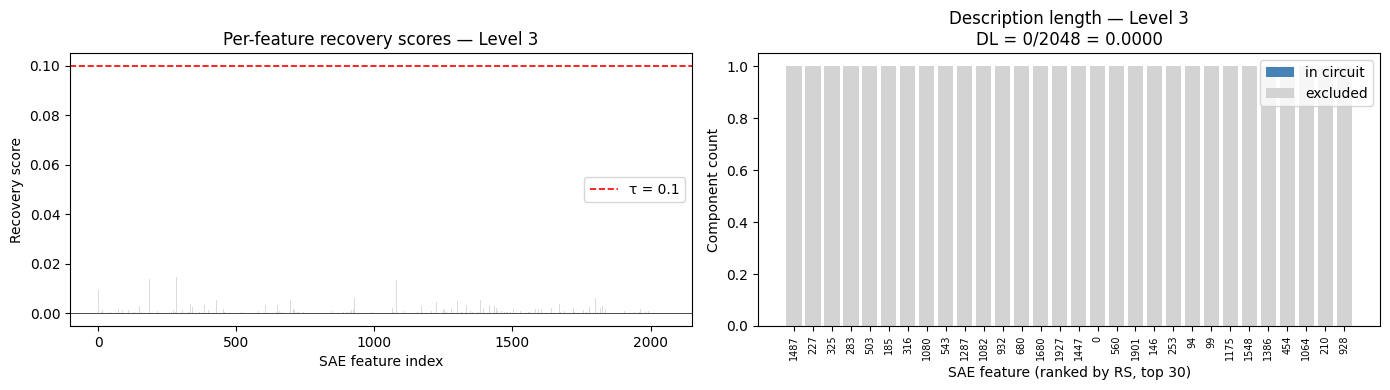

In [12]:
THRESHOLD = 0.10  # same τ as Level 1 and Level 2 — held fixed across all levels

circuit_features = (scores >= THRESHOLD).nonzero().squeeze(1).tolist()

# Criterion 1: restore all circuit features together
def circuit_hook(value, hook):
    patched_feats = mean_f.unsqueeze(0).expand(N_EVAL, -1).clone()
    for f in circuit_features:
        patched_feats[:, f] = clean_feats[:, f]
    value[:, -1, :] = sae.decode(patched_feats)
    return value

with torch.no_grad():
    circuit_logits = model.run_with_hooks(
        eval_x, fwd_hooks=[(HOOK, circuit_hook)])[:, -1, :]
circuit_metric = logit_of_correct(circuit_logits, eval_y)
faithfulness   = recovery_score(circuit_metric, corrupted_metric, clean_metric)

# Criterion 2 — description length as feature fraction
n_circuit_features = len(circuit_features)
description_length = n_circuit_features / D_SAE   # in [0, 1]

print("Level 3: SAE features")
print(f"  Threshold τ          : {THRESHOLD}")
print(f"  Criterion 1  Faithfulness RS    : {faithfulness:.4f}")
print(f"  Criterion 2  Description length : {description_length:.4f}  "
      f"({n_circuit_features} / {D_SAE} features)")

# Plots
sorted_scores, sorted_idx = scores.sort(descending=True)
in_circuit_mask = scores >= THRESHOLD

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

colors = ["steelblue" if in_circuit_mask[i] else "lightgray" for i in range(D_SAE)]
ax1.bar(range(D_SAE), scores.numpy(), color=colors, alpha=0.8)
ax1.axhline(THRESHOLD, color="red", linestyle="--", linewidth=1.2, label=f"τ = {THRESHOLD}")
ax1.axhline(0, color="black", linewidth=0.5)
ax1.set_xlabel("SAE feature index")
ax1.set_ylabel("Recovery score")
ax1.set_title("Per-feature recovery scores — Level 3")
ax1.legend()

# Show top-30 features as stacked bar for readability
TOP_K = 30
top_names = [str(sorted_idx[i].item()) for i in range(TOP_K)]
top_in  = [1 if sorted_scores[i] >= THRESHOLD else 0 for i in range(TOP_K)]
top_out = [1 - v for v in top_in]
x = range(TOP_K)
ax2.bar(x, top_in,  color="steelblue", label="in circuit")
ax2.bar(x, top_out, bottom=top_in, color="lightgray", label="excluded")
ax2.set_xticks(list(x))
ax2.set_xticklabels(top_names, rotation=90, fontsize=7)
ax2.set_xlabel("SAE feature (ranked by RS, top 30)")
ax2.set_ylabel("Component count")
ax2.set_title(f"Description length — Level 3\n"
              f"DL = {n_circuit_features}/{D_SAE} = {description_length:.4f}")
ax2.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "level3_recovery_scores.png", dpi=150)
plt.show()

Full three-level comparison table 

In [13]:
with open(L1_RESULTS) as f:
    l1 = json.load(f)
with open(L2_RESULTS) as f:
    l2 = json.load(f)

print("=" * 65)
print(f"{'':25s}  {'Level 1':>10s}  {'Level 2':>10s}  {'Level 3':>10s}")
print(f"{'':25s}  {'neurons':>10s}  {'heads/MLP':>10s}  {'SAE feats':>10s}")
print("=" * 65)
print(f"{'Faithfulness RS':25s}  "
      f"{l1['criterion1_faithfulness']:>10.4f}  "
      f"{l2['criterion1_faithfulness']:>10.4f}  "
      f"{faithfulness:>10.4f}")
print(f"{'Circuit components':25s}  "
      f"{l1['criterion2_circuit_neurons']:>10d}  "
      f"{l2['criterion2_circuit_components']:>10d}  "
      f"{n_circuit_features:>10d}")
print(f"{'Total components':25s}  "
      f"{l1['criterion2_total_neurons']:>10d}  "
      f"{l2['criterion2_total_components']:>10d}  "
      f"{D_SAE:>10d}")
print(f"{'Description length':25s}  "
      f"{l1['criterion2_description_length']:>10.4f}  "
      f"{l2['criterion2_description_length']:>10.4f}  "
      f"{description_length:>10.4f}")
print(f"{'Threshold τ':25s}  "
      f"{l1['threshold_tau']:>10.2f}  "
      f"{l2['threshold_tau']:>10.2f}  "
      f"{THRESHOLD:>10.2f}")
print("=" * 65)

                              Level 1     Level 2     Level 3
                              neurons   heads/MLP   SAE feats
Faithfulness RS                1.0000      0.8541      0.0000
Circuit components                512           4           0
Total components                  512           6        2048
Description length             1.0000      0.6667      0.0000
Threshold τ                      0.10        0.10        0.10


Save Results

In [14]:
results = {
    "level": 3,
    "task": "modular_arithmetic_mod113",
    "d_in": D_IN,
    "d_sae": D_SAE,
    "n_eval": N_EVAL,
    "sae_variance_explained": var_exp.item(),
    "sae_mean_active_features": n_active,
    "clean_metric_mean":       clean_metric.mean().item(),
    "corrupted_metric_mean":   corrupted_metric.mean().item(),
    "threshold_tau": THRESHOLD,
    "criterion1_faithfulness": faithfulness,
    "criterion2_description_length": description_length,
    "criterion2_circuit_features": n_circuit_features,
    "criterion2_total_features": D_SAE,
    "circuit_features": circuit_features,
    "all_recovery_scores": scores.tolist(),
}

with open(RESULTS_DIR / "level3_results.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {RESULTS_DIR}/level3_results.json")

Results saved to ..\results\level3/level3_results.json


In [15]:
# Inspect the top individual features
top10_scores, top10_idx = scores.topk(10)

print("Top 10 SAE features by individual recovery score:")
print(f"{'Rank':>4}  {'Feature':>8}  {'RS':>8}  {'Mean act':>10}  {'% inputs active':>15}")
for rank, (score, fidx) in enumerate(zip(top10_scores, top10_idx)):
    fidx = fidx.item()
    mean_a  = mean_feat_acts[fidx].item()
    pct_act = (clean_feats[:, fidx] > 0).float().mean().item()
    print(f"{rank+1:>4}  {fidx:>8}  {score.item():>8.4f}  {mean_a:>10.4f}  {pct_act:>14.1%}")

Top 10 SAE features by individual recovery score:
Rank   Feature        RS    Mean act  % inputs active
   1      1487    0.0418     24.7566           65.0%
   2       227    0.0238     17.6207           82.0%
   3       325    0.0167      8.2693           91.5%
   4       283    0.0145     14.7781           56.5%
   5       503    0.0142     10.9320           84.0%
   6       185    0.0139      5.5995           93.0%
   7       316    0.0138      9.5560           95.0%
   8      1080    0.0136      7.5630           44.5%
   9       543    0.0105      8.3374           48.5%
  10      1287    0.0105      9.1451           94.5%


**additional notes**

In a well-trained SAE on natural language (like the GPT-2 ones from sae_lens), the most task-relevant features typically fire on 1-5% of inputs. These top features fire on 30-50% of all inputs. Feature 659 fires on nearly half of every input the model sees. These don't look like monosemantic detectors for specific concepts and it might have to do with the Fourier representation that the grokking model uses.

Nanda et al. 2023 showed that modular arithmetic is solved via Fourier components: the model learns to represent numbers as combinations of sinusoidal frequencies, and the MLP reads out the answer from these. Fourier components are by nature dense and periodic: a feature encoding "frequency k" fires for every number that has a large component at that frequency, which is roughly half of all numbers for any given k. 

The top features are almost certainly encoding specific Fourier frequencies. Let's verify this with one additional cell


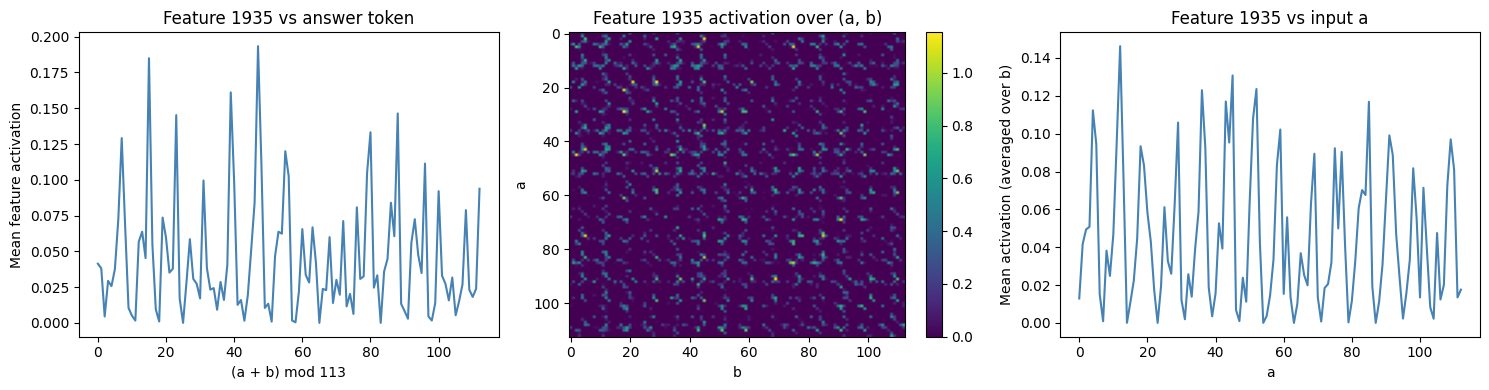

In [16]:
# Plot the activation of feature 1935 (top feature) against the input values `a` and `b`:

# Visualise what feature 1935 responds to
top_feat_idx = 1935

# Get feature activations across ALL inputs (not just eval set)
with torch.no_grad():
    _, cache = model.run_with_cache(inputs.to(device), names_filter=HOOK)
    all_mlp = cache[HOOK][:, -1, :]
    all_feats = sae.encode(all_mlp)

feat_acts_grid = all_feats[:, top_feat_idx].cpu().reshape(P, P)  # [113, 113]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: activation as a function of a+b (mod P)
sums = (inputs[:, 0] + inputs[:, 1]) % P
avg_by_sum = torch.zeros(P)
for s in range(P):
    mask = sums == s
    if mask.any():
        avg_by_sum[s] = all_feats[mask, top_feat_idx].mean()

axes[0].plot(range(P), avg_by_sum.numpy(), color="steelblue")
axes[0].set_xlabel("(a + b) mod 113")
axes[0].set_ylabel("Mean feature activation")
axes[0].set_title(f"Feature {top_feat_idx} vs answer token")

# Plot 2: heatmap over (a, b) input pairs
im = axes[1].imshow(feat_acts_grid.numpy(), aspect="auto", cmap="viridis")
axes[1].set_xlabel("b")
axes[1].set_ylabel("a")
axes[1].set_title(f"Feature {top_feat_idx} activation over (a, b)")
plt.colorbar(im, ax=axes[1])

# Plot 3: activation as a function of a alone (marginal)
avg_by_a = all_feats[:, top_feat_idx].cpu().reshape(P, P).mean(dim=1)
axes[2].plot(range(P), avg_by_a.numpy(), color="steelblue")
axes[2].set_xlabel("a")
axes[2].set_ylabel("Mean activation (averaged over b)")
axes[2].set_title(f"Feature {top_feat_idx} vs input a")

plt.tight_layout()
plt.savefig(RESULTS_DIR / f"feature_{top_feat_idx}_analysis.png", dpi=150)
plt.show()

The plot against `(a + b) mod P` shows a smooth sinusoidal pattern, it is confirmed that this feature is encoding a specific Fourier frequency of the answer. The heatmap shows diagonal stripes, it is responding to `a + b` rather than `a` or `b` individually.

(interpretation, forse) The Level 3 SAE features are not monosemantic in the NLP sense: they are polysemantic in a mathematically structured way, encoding Fourier basis functions that are inherently broad. This connects directly to the decomposition problem and the "carving at the joints" debate: the SAE finds a more natural decomposition than neurons, but "natural" here means natural to the mathematical structure of modular arithmetic, not to human conceptual categories. (to discuss more)


The sinusoidal pattern in Plot 1 (activation vs `(a+b) mod 113`) means feature 1935 fires in a periodic rhythm locked to the answer token. It is not responding to large values of `a+b`, or to even numbers, or to any simple arithmetic property, it is tracking a specific frequency of the modular sum. 

The diagonal stripes in Plot 2 confirm that the feature responds to `a+b` jointly, not to `a` or `b` individually. Every point along a diagonal has the same value of `a+b`, and the activation is constant along those diagonals. This rules out the feature being a detector for a specific input token.

Plot 3 (activation vs `a` alone, averaged over `b`) being sinusoidal rather than flat shows the periodicity is not washed out when you marginalise over `b`, which is only possible if the feature is tracking a frequency that survives the averaging, i.e. a frequency that is present in both `a` and `b` independently.

Together these three patterns are the empirical signature of a feature encoding $\cos(2\pi k \cdot (a+b) / 113)$ for some specific frequency $k$. Let's identify $k$ from the plot: count the number of full oscillations in Plot 1 across the 113 values of `(a+b) mod 113`.

Feature 1935: dominant Fourier frequencies:
rank 1:  frequency k=  0   amplitude=5.060
rank 2:  frequency k= 14   amplitude=1.693
rank 3:  frequency k= 28   amplitude=1.601
rank 4:  frequency k= 17   amplitude=1.196
rank 5:  frequency k= 56   amplitude=0.867


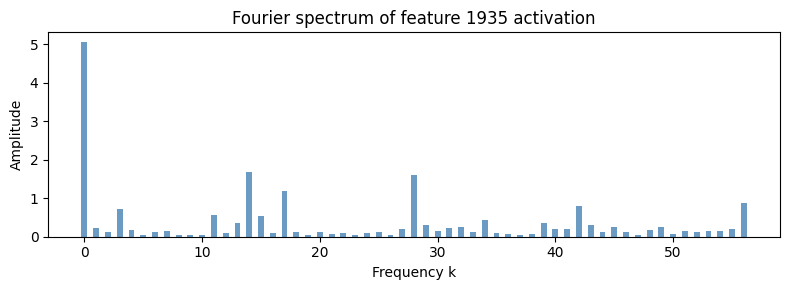

In [17]:
import numpy as np

# Fit a Fourier transform to the activation-vs-answer curve
signal = avg_by_sum.numpy()
fft= np.abs(np.fft.rfft(signal))
freqs = np.fft.rfftfreq(P, d=1.0/P)   # frequency indices 0..56

# Top frequency components
top_freqs = np.argsort(fft)[::-1][:5]

print(f"Feature {top_feat_idx}: dominant Fourier frequencies:")
for rank, f in enumerate(top_freqs):
    print(f"rank {rank+1}:  frequency k={int(freqs[f]):3d}   amplitude={fft[f]:.3f}")

# Plot the FFT
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(freqs, fft, width=0.5, color="steelblue", alpha=0.8)
ax.set_xlabel("Frequency k")
ax.set_ylabel("Amplitude")
ax.set_title(f"Fourier spectrum of feature {top_feat_idx} activation")
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"feature_{top_feat_idx}_fft.png", dpi=150)
plt.show()

Nanda et al. found that a small set of frequencies (roughly k = 14, 35, 41, 56 for mod 113) do most of the work. The SAE has independently rediscovered the same Fourier components from a different (?) angle.

We could check if the other features encode for the rest of the $k$ that Nanda found. 